## Data Cleaning, Preprocessing, and EDA.

###### Data Source (UCI credit card default) https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

- Fixes invalid categories
- Keeps PAY variables untouched despite invalid values in PAY_0,...,PAY_6. Removing data may result in a significant reduction in observations and a suitable imputation method was not identified.
- Encodes categorical variables properly
- Data preparation for: logistic regression, ridge/lasso


#### Data docs:
y: default payment (Yes = 1, No = 0). 

X1: Amount of the given credit (NT dollar): it includes both the individual consumer credit and his/her family (supplementary) credit.
X2: Gender (1 = male; 2 = female).
X3: Education (1 = graduate school; 2 = university; 3 = high school; 4 = others).
X4: Marital status (1 = married; 2 = single; 3 = others).
X5: Age (year).

###### X6 - X11: Past monthly payment records (from April to September, 2005) 
X6 = the repayment status in September, 2005; 
X7 = the repayment status in August, 2005; 
. . .;
X11 = the repayment status in April, 2005. 

The measurement scale for the repayment status is: -1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above.

###### X12-X17: Amount of bill statement (NT dollar). 
X12 = amount of bill statement in September, 2005; 
X13 = amount of bill statement in August, 2005; 
. . .; 
X17 = amount of bill statement in April, 2005. 

###### X18-X23: Amount of previous payment (NT dollar). 
X18 = amount paid in September, 2005; 
X19 = amount paid in August, 2005;
. . .;
X23 = amount paid in April, 2005.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    log_loss,
    accuracy_score,
    confusion_matrix,
)

### Data Cleaning

In [21]:
# load data
default_of_credit_card_clients = fetch_ucirepo(id=350)

X = default_of_credit_card_clients.data.features.copy()
y = default_of_credit_card_clients.data.targets.copy()

# If y is a one-column DataFrame, convert to a Series
if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target unique values:", sorted(y.unique()))

X shape: (30000, 23)
y shape: (30000,)
Target unique values: [np.int64(0), np.int64(1)]


In [22]:
# rename columns
rename_map = {
    "X1": "LIMIT_BAL",
    "X2": "SEX",
    "X3": "EDUCATION",
    "X4": "MARRIAGE",
    "X5": "AGE",
    "X6": "PAY_0",
    "X7": "PAY_2",
    "X8": "PAY_3",
    "X9": "PAY_4",
    "X10": "PAY_5",
    "X11": "PAY_6",
    "X12": "BILL_AMT1",
    "X13": "BILL_AMT2",
    "X14": "BILL_AMT3",
    "X15": "BILL_AMT4",
    "X16": "BILL_AMT5",
    "X17": "BILL_AMT6",
    "X18": "PAY_AMT1",
    "X19": "PAY_AMT2",
    "X20": "PAY_AMT3",
    "X21": "PAY_AMT4",
    "X22": "PAY_AMT5",
    "X23": "PAY_AMT6",
}

X = X.rename(columns=rename_map)
y = y.rename("DEFAULT")

print("\nRenamed columns:")
print(X.columns.tolist())


Renamed columns:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [23]:
# ensure validity of data value and data type

# education: collapse undocumented categories
X["EDUCATION"] = X["EDUCATION"].replace({0: 4, 5: 4, 6: 4})

# marriage: collapse undocumented category
X["MARRIAGE"] = X["MARRIAGE"].replace({0: 3})

# convert to categorical
categorical_cols = ["SEX", "EDUCATION", "MARRIAGE"]

for col in categorical_cols:
    X[col] = X[col].astype("category")

# pay variables
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

# Ensure numeric (no transformation)
X[pay_cols] = X[pay_cols].astype(int)

In [24]:
# define variable groups
financial_cols = [
    "LIMIT_BAL",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6",
]

behavioral_cols = pay_cols

demographic_cols = ["SEX", "EDUCATION", "MARRIAGE", "AGE"]

In [25]:
# train-test split (5 fold cross validation)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
# preprocessing for models

# Separate numeric vs categorical
numeric_cols = [col for col in X.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
    ]
)

# Fit-transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# -----------------------------
# 9. Sanity checks
# -----------------------------
print("Shapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nDefault rate:")
print("Train:", y_train.mean())
print("Test:", y_test.mean())

print("\nProcessed shapes:")
print(X_train_processed.shape)
print(X_test_processed.shape)

Shapes:
X_train: (24000, 23)
X_test: (6000, 23)

Default rate:
Train: 0.22120833333333334
Test: 0.22116666666666668

Processed shapes:
(24000, 26)
(6000, 26)


In [27]:
X

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000,1,3,1,39,0,0,0,0,0,...,208365,88004,31237,15980,8500,20000,5003,3047,5000,1000
29996,150000,1,3,2,43,-1,-1,-1,-1,0,...,3502,8979,5190,0,1837,3526,8998,129,0,0
29997,30000,1,2,2,37,4,3,2,-1,0,...,2758,20878,20582,19357,0,0,22000,4200,2000,3100
29998,80000,1,3,1,41,1,-1,0,0,0,...,76304,52774,11855,48944,85900,3409,1178,1926,52964,1804


In [28]:
y

0        1
1        1
2        0
3        0
4        0
        ..
29995    0
29996    0
29997    1
29998    1
29999    1
Name: DEFAULT, Length: 30000, dtype: int64

### Exploratory Analysis


Conclusions:
1. Behavioral variables dominate prediction
- repayment status strongly correlates with default
- even small delays drastically increase risk
2. Financial variables have weaker, smoother effects
- credit limit shows monotonic trend
- but less separation than behavior
3. Strong multicollinearity exists. Especially within:
- bill amounts
- payment amounts
- repayment history
4. Distributions are highly skewed
- financial variables have heavy tails
- potential impact on regression stability

#### 1. Basic Structure + Missing Values

Why:
- sanity check dataset integrity
- confirm no missingness issues

What we found:
- no missing values
- all variables populated

Implication:
- no imputation needed
- no selection bias from missingness

In [29]:
df = X.copy()
df["DEFAULT"] = y

# basic data structure
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nDtypes:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nTarget distribution:")
print(df["DEFAULT"].value_counts(dropna=False).sort_index())
print("\nTarget proportion:")
print(df["DEFAULT"].value_counts(normalize=True).sort_index())

Shape: (30000, 24)

Columns:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT']

Dtypes:
LIMIT_BAL       int64
SEX          category
EDUCATION    category
MARRIAGE     category
AGE             int64
PAY_0           int64
PAY_2           int64
PAY_3           int64
PAY_4           int64
PAY_5           int64
PAY_6           int64
BILL_AMT1       int64
BILL_AMT2       int64
BILL_AMT3       int64
BILL_AMT4       int64
BILL_AMT5       int64
BILL_AMT6       int64
PAY_AMT1        int64
PAY_AMT2        int64
PAY_AMT3        int64
PAY_AMT4        int64
PAY_AMT5        int64
PAY_AMT6        int64
DEFAULT         int64
dtype: object

Missing values:
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0


In [30]:
# Summary statistics

print("\nSummary statistics:")
print(df.describe().T)


Summary statistics:
             count           mean            std       min       25%  \
LIMIT_BAL  30000.0  167484.322667  129747.661567   10000.0  50000.00   
AGE        30000.0      35.485500       9.217904      21.0     28.00   
PAY_0      30000.0      -0.016700       1.123802      -2.0     -1.00   
PAY_2      30000.0      -0.133767       1.197186      -2.0     -1.00   
PAY_3      30000.0      -0.166200       1.196868      -2.0     -1.00   
PAY_4      30000.0      -0.220667       1.169139      -2.0     -1.00   
PAY_5      30000.0      -0.266200       1.133187      -2.0     -1.00   
PAY_6      30000.0      -0.291100       1.149988      -2.0     -1.00   
BILL_AMT1  30000.0   51223.330900   73635.860576 -165580.0   3558.75   
BILL_AMT2  30000.0   49179.075167   71173.768783  -69777.0   2984.75   
BILL_AMT3  30000.0   47013.154800   69349.387427 -157264.0   2666.25   
BILL_AMT4  30000.0   43262.948967   64332.856134 -170000.0   2326.75   
BILL_AMT5  30000.0   40311.400967   60797.1

#### 2. Target distribution

Why:
- understand baseline difficulty
- check imbalance

What we found:
- ~22% default rate

Implication:
- moderately imbalanced, but not severe
- logistic regression is fine without heavy adjustment


Overall default rate: 0.2212


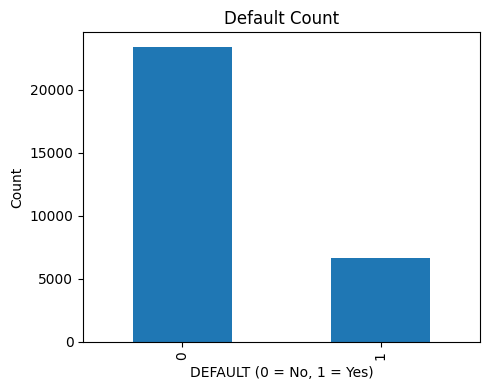

In [31]:
# overall default rate
default_rate = df["DEFAULT"].mean()
print("\nOverall default rate:", round(default_rate, 4))

plt.figure(figsize=(5,4))
df["DEFAULT"].value_counts().sort_index().plot(kind="bar")
plt.title("Default Count")
plt.xlabel("DEFAULT (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#### 3. Summary statistics

Why:
- understand scale differences
- detect skew/outliers

What we found:
- financial variables (BILL_AMT, PAY_AMT) extremely skewed
- large spread and extreme values

Implication:
- potential leverage issues
- scaling matters for ridge/lasso
- transformation might be considered later

#### 4. Default rate by categorical variables

Why:
- check if demographics matter

What we found:
- SEX, MARRIAGE → small differences
- EDUCATION → noisy / inconsistent

Implication:
- weak predictors
- unlikely to drive results
- include but don’t focus

#### 5. Default rate by repayment status (PAY variables)

Why:
- test behavioral signal

What we found:
- massive monotonic increase in default with delay
- even small delays → large jumps in default probability

Implication (CRITICAL):
- Repayment behavior is the strongest predictor in the dataset
- This is the centerpiece of the project

#### 6. Default rate by LIMIT_BAL (financial variable)

Why:
- test financial signal independently

What you found:
- clear monotonic relationship
- lower limit → higher default

Implication:
- financial variables contain signal but weaker and smoother than behavioral

#### 7. Distributions (histograms)

Why:
- detect skew and outliers

What we found:
- heavy right skew
- mass near zero
- extreme outliers

Implication:
- linear models may be sensitive
- log transforms might help (optional)

#### 8. Boxplots by default

Why:
- compare distributions between groups

What we found:
- defaulters: lower credit limits and slightly different distributions but strong overlap

Implication:
- financial variables are not strongly separating
- behavioral variables likely dominate

#### 9. Correlation analysis (MOST IMPORTANT)

Why:
- detect multicollinearity

What we found:
- Extreme within-group correlation:
BILL_AMT: ~0.9+
PAY_AMT: ~0.7–0.8
PAY: ~0.7–0.8
- Moderate cross-group:
financial ↔ behavioral

Implication (CRITICAL):
- You have strong multicollinearity and redundancy

This directly supports the project theme: coefficient instability + interpretability issues


Default rate by SEX:
SEX
1    0.241672
2    0.207763
Name: DEFAULT, dtype: float64


C:\Users\kxu97\AppData\Local\Temp\ipykernel_392\874831971.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = df.groupby(col)["DEFAULT"].mean().sort_index()


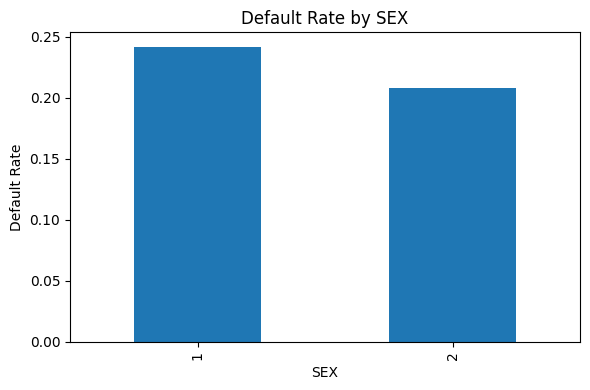

C:\Users\kxu97\AppData\Local\Temp\ipykernel_392\874831971.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = df.groupby(col)["DEFAULT"].mean().sort_index()



Default rate by EDUCATION:
EDUCATION
1    0.192348
2    0.237349
3    0.251576
4    0.070513
Name: DEFAULT, dtype: float64


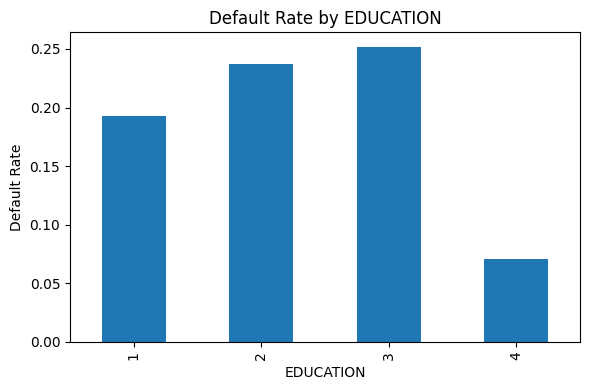

C:\Users\kxu97\AppData\Local\Temp\ipykernel_392\874831971.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = df.groupby(col)["DEFAULT"].mean().sort_index()



Default rate by MARRIAGE:
MARRIAGE
1    0.234717
2    0.209283
3    0.236074
Name: DEFAULT, dtype: float64


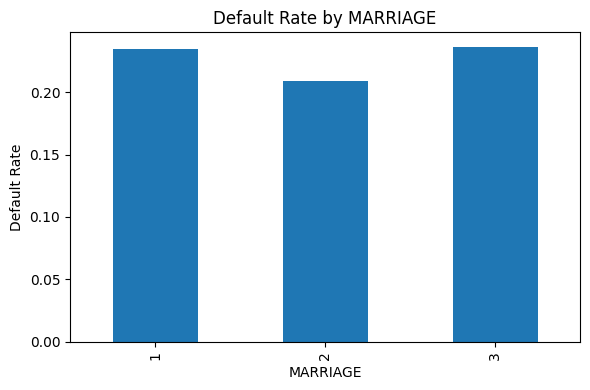


Default rate by PAY_0:
PAY_0
-2    0.132294
-1    0.167781
 0    0.128113
 1    0.339479
 2    0.691414
 3    0.757764
 4    0.684211
 5    0.500000
 6    0.545455
 7    0.777778
 8    0.578947
Name: DEFAULT, dtype: float64


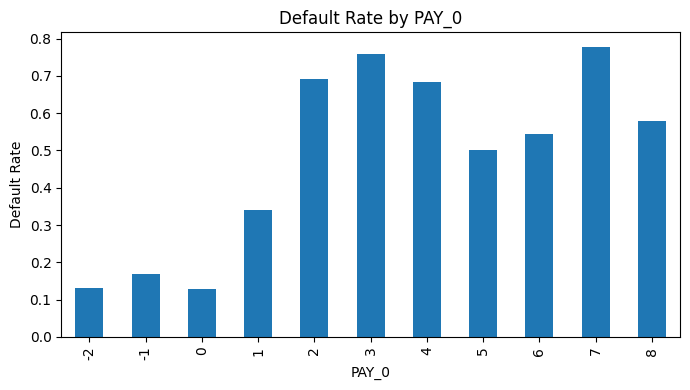


Default rate by PAY_2:
PAY_2
-2    0.182708
-1    0.159669
 0    0.159123
 1    0.178571
 2    0.556150
 3    0.616564
 4    0.505051
 5    0.600000
 6    0.750000
 7    0.600000
 8    0.000000
Name: DEFAULT, dtype: float64


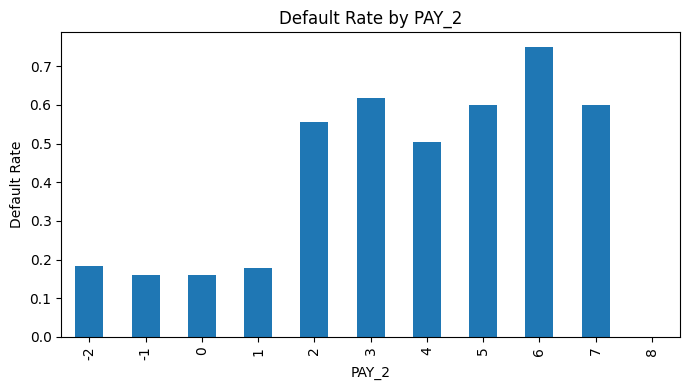


Default rate by PAY_3:
PAY_3
-2    0.185312
-1    0.155945
 0    0.174512
 1    0.250000
 2    0.515580
 3    0.575000
 4    0.578947
 5    0.571429
 6    0.608696
 7    0.814815
 8    0.666667
Name: DEFAULT, dtype: float64


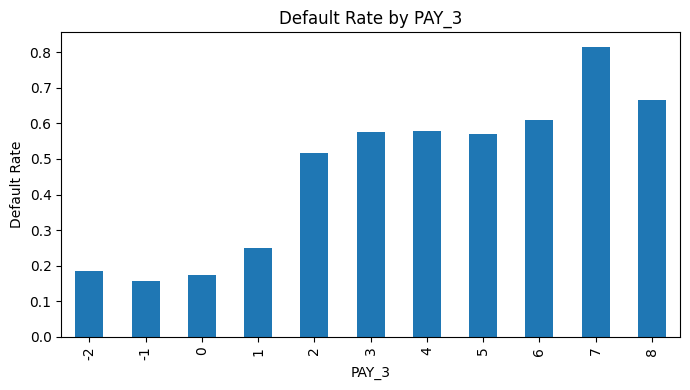


Default rate by PAY_4:
PAY_4
-2    0.192502
-1    0.158959
 0    0.183288
 1    0.500000
 2    0.523267
 3    0.611111
 4    0.666667
 5    0.514286
 6    0.400000
 7    0.827586
 8    0.500000
Name: DEFAULT, dtype: float64


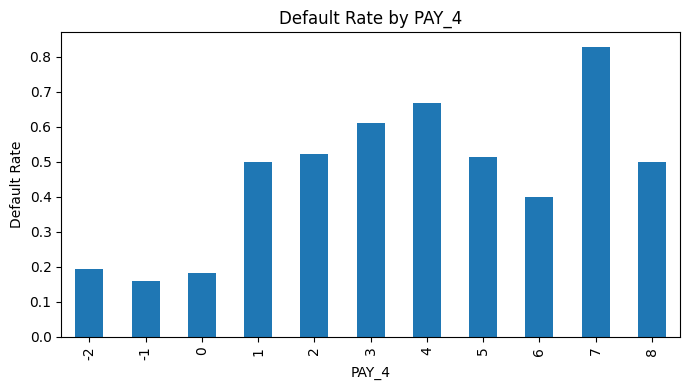


Default rate by PAY_5:
PAY_5
-2    0.196876
-1    0.161943
 0    0.188529
 2    0.541889
 3    0.634831
 4    0.607143
 5    0.588235
 6    0.750000
 7    0.827586
 8    1.000000
Name: DEFAULT, dtype: float64


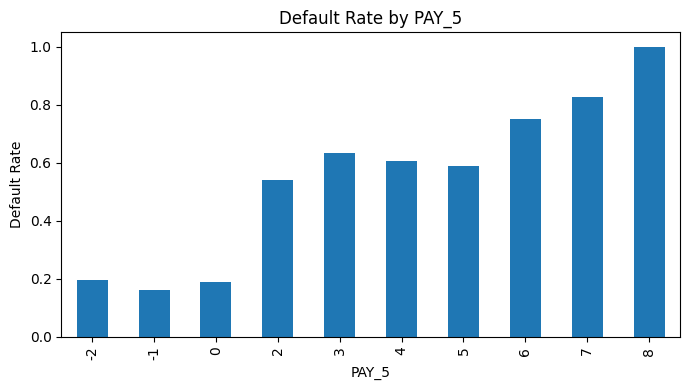


Default rate by PAY_6:
PAY_6
-2    0.200409
-1    0.169861
 0    0.188444
 2    0.506508
 3    0.641304
 4    0.632653
 5    0.538462
 6    0.736842
 7    0.826087
 8    1.000000
Name: DEFAULT, dtype: float64


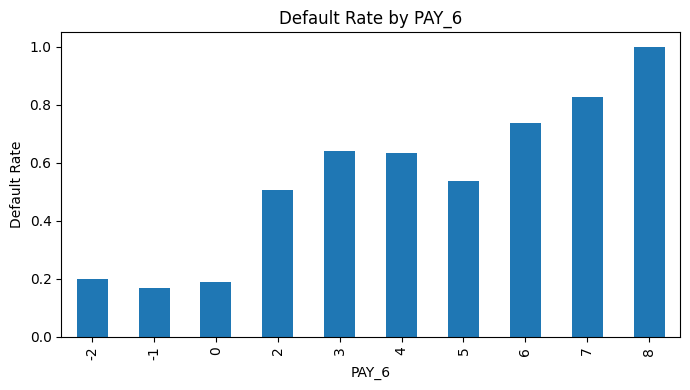


Default rate by LIMIT_BAL decile:
LIMIT_BAL_Q
(9999.999, 30000.0]      0.358491
(30000.0, 50000.0]       0.271766
(50000.0, 70000.0]       0.284704
(70000.0, 100000.0]      0.245254
(100000.0, 140000.0]     0.228510
(140000.0, 180000.0]     0.173521
(180000.0, 210000.0]     0.175312
(210000.0, 270000.0]     0.162918
(270000.0, 360000.0]     0.151637
(360000.0, 1000000.0]    0.118740
Name: DEFAULT, dtype: float64


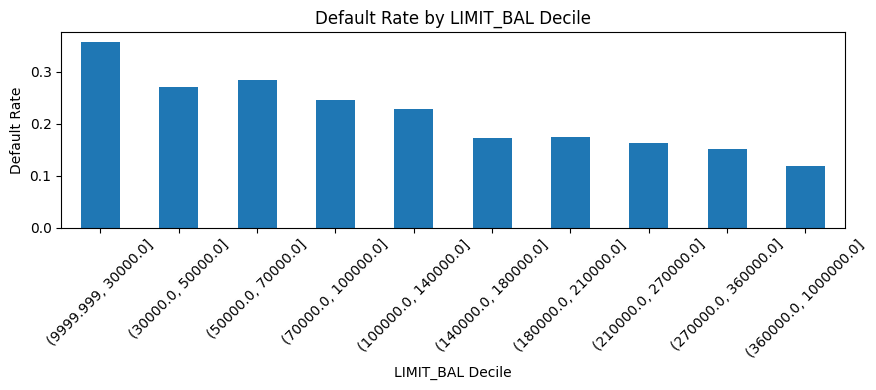

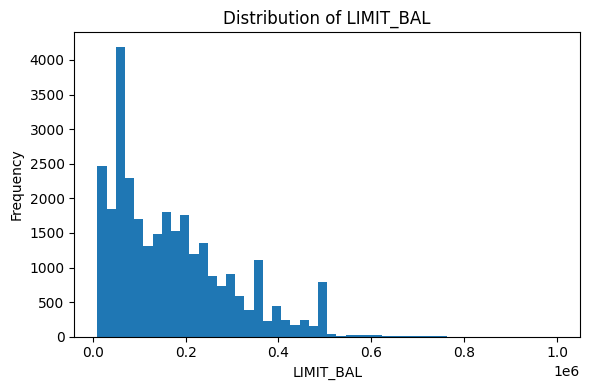

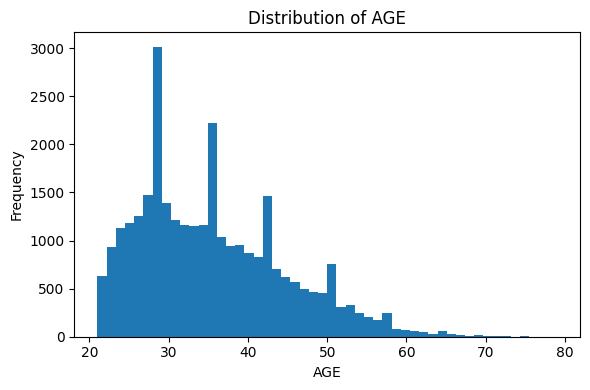

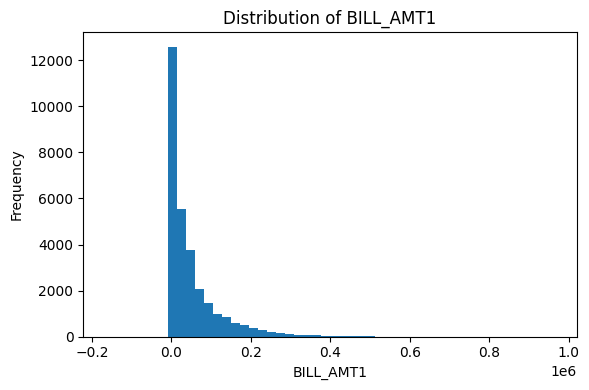

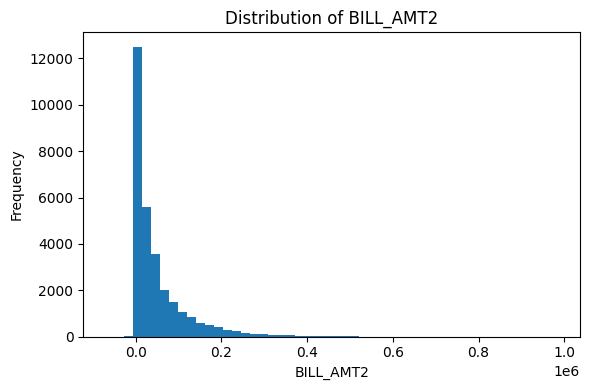

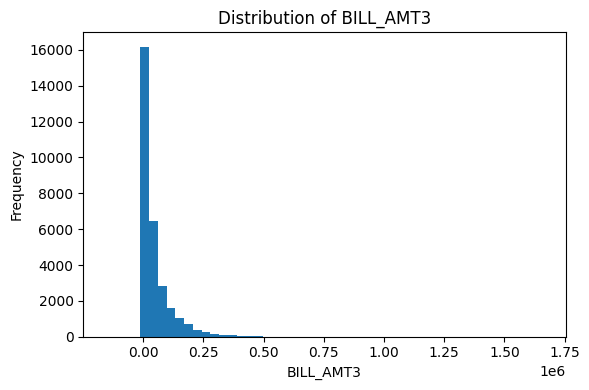

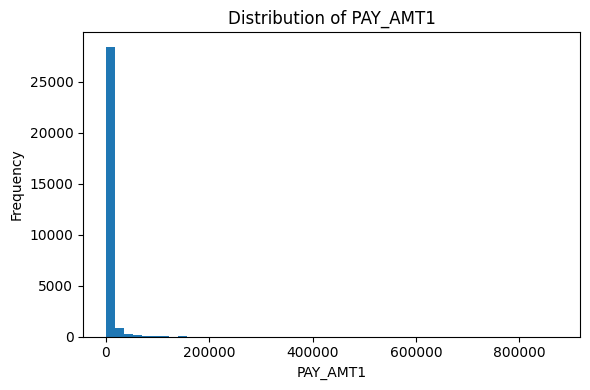

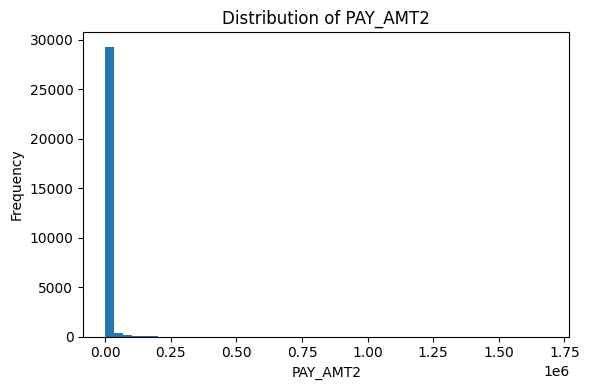

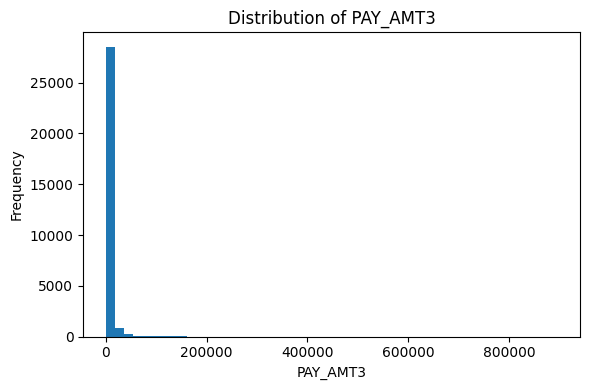

<Figure size 600x400 with 0 Axes>

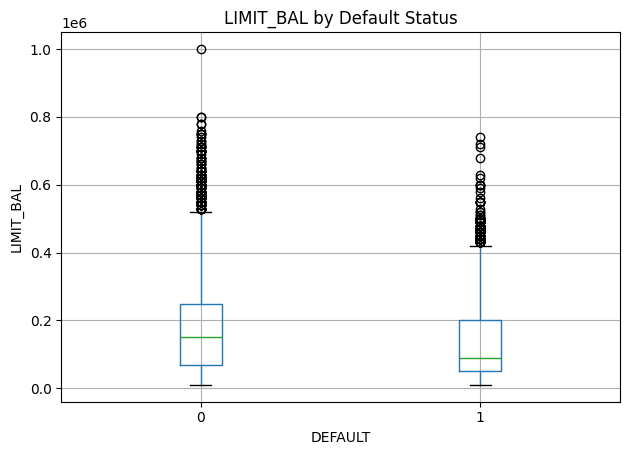

<Figure size 600x400 with 0 Axes>

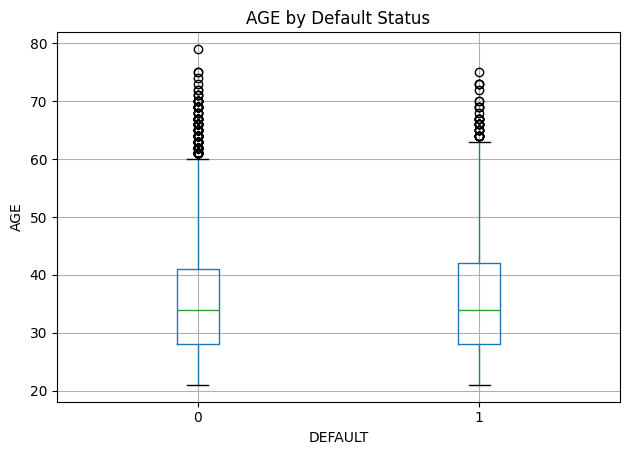

<Figure size 600x400 with 0 Axes>

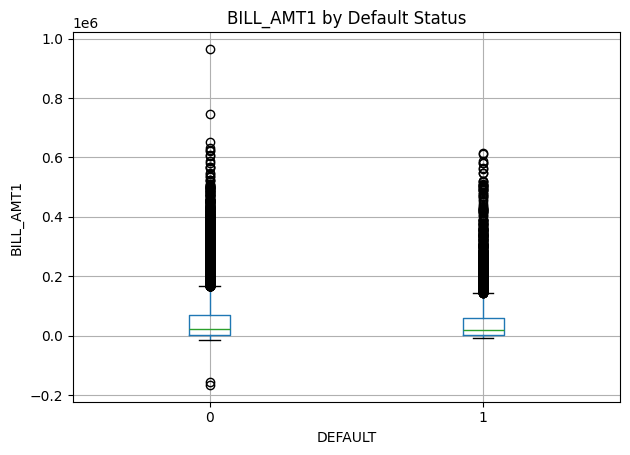

<Figure size 600x400 with 0 Axes>

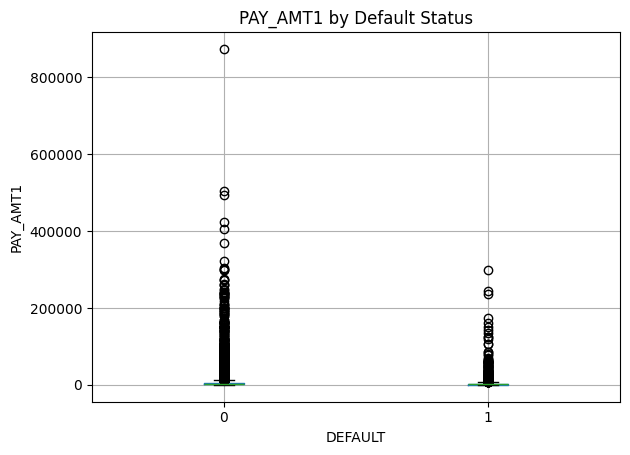


Top absolute correlations:
BILL_AMT2  BILL_AMT1    0.951484
BILL_AMT5  BILL_AMT6    0.946197
           BILL_AMT4    0.940134
BILL_AMT2  BILL_AMT3    0.928326
BILL_AMT3  BILL_AMT4    0.923969
BILL_AMT6  BILL_AMT4    0.900941
BILL_AMT2  BILL_AMT4    0.892482
BILL_AMT3  BILL_AMT1    0.892279
           BILL_AMT5    0.883910
BILL_AMT4  BILL_AMT1    0.860272
BILL_AMT5  BILL_AMT2    0.859778
BILL_AMT6  BILL_AMT3    0.853320
           BILL_AMT2    0.831594
BILL_AMT1  BILL_AMT5    0.829779
PAY_4      PAY_5        0.819835
PAY_5      PAY_6        0.816900
BILL_AMT6  BILL_AMT1    0.802650
PAY_4      PAY_3        0.777359
PAY_2      PAY_3        0.766552
PAY_4      PAY_6        0.716449
dtype: float64


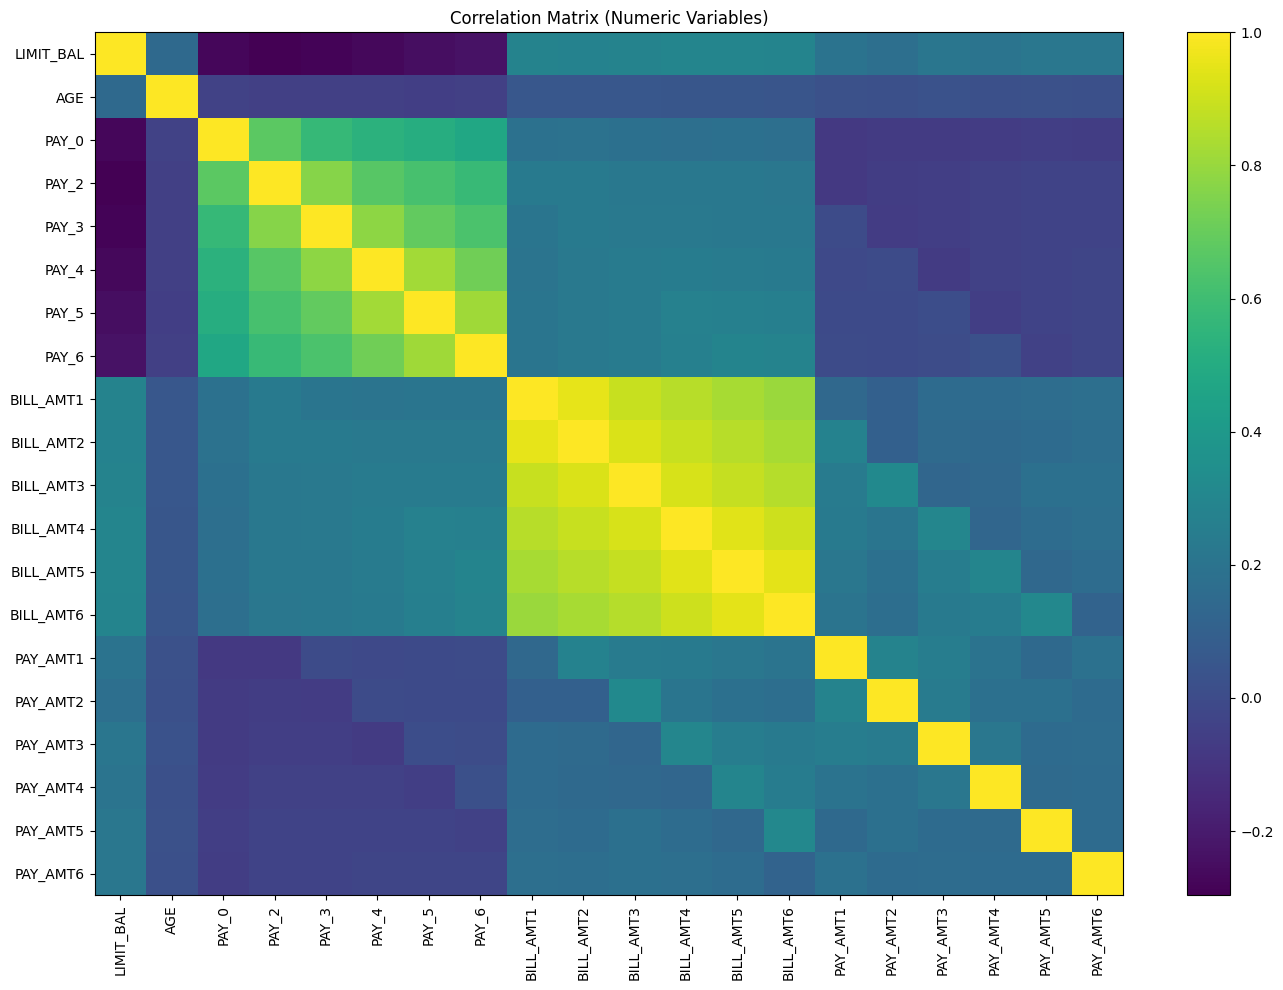

In [32]:
# Default rates by categorical variables

cat_cols = ["SEX", "EDUCATION", "MARRIAGE"]

for col in cat_cols:
    tab = df.groupby(col)["DEFAULT"].mean().sort_index()
    print(f"\nDefault rate by {col}:")
    print(tab)

    plt.figure(figsize=(6,4))
    tab.plot(kind="bar")
    plt.title(f"Default Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Default Rate")
    plt.tight_layout()
    plt.show()

# Default rates by repayment status

pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

for col in pay_cols:
    tab = df.groupby(col)["DEFAULT"].mean().sort_index()
    print(f"\nDefault rate by {col}:")
    print(tab)

    plt.figure(figsize=(7,4))
    tab.plot(kind="bar")
    plt.title(f"Default Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Default Rate")
    plt.tight_layout()
    plt.show()

# Credit limit quantiles vs default
df["LIMIT_BAL_Q"] = pd.qcut(df["LIMIT_BAL"], q=10, duplicates="drop")

limit_tab = df.groupby("LIMIT_BAL_Q", observed=False)["DEFAULT"].mean()
print("\nDefault rate by LIMIT_BAL decile:")
print(limit_tab)

plt.figure(figsize=(9,4))
limit_tab.plot(kind="bar")
plt.title("Default Rate by LIMIT_BAL Decile")
plt.xlabel("LIMIT_BAL Decile")
plt.ylabel("Default Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Histograms for key continuous variables
cont_cols = [
    "LIMIT_BAL", "AGE",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3"
]

for col in cont_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# Boxplots by default status
box_cols = ["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1"]

for col in box_cols:
    plt.figure(figsize=(6,4))
    df.boxplot(column=col, by="DEFAULT")
    plt.title(f"{col} by Default Status")
    plt.suptitle("")
    plt.xlabel("DEFAULT")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

# Correlation matrix for numeric variables

numeric_df = df.select_dtypes(include=[np.number]).drop(columns=["DEFAULT"])

corr = numeric_df.corr()

print("\nTop absolute correlations:")
corr_abs = corr.abs().where(~np.eye(corr.shape[0], dtype=bool))
top_corr = (
    corr_abs.stack()
    .sort_values(ascending=False)
    .drop_duplicates()
    .head(20)
)
print(top_corr)

plt.figure(figsize=(14,10))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.title("Correlation Matrix (Numeric Variables)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

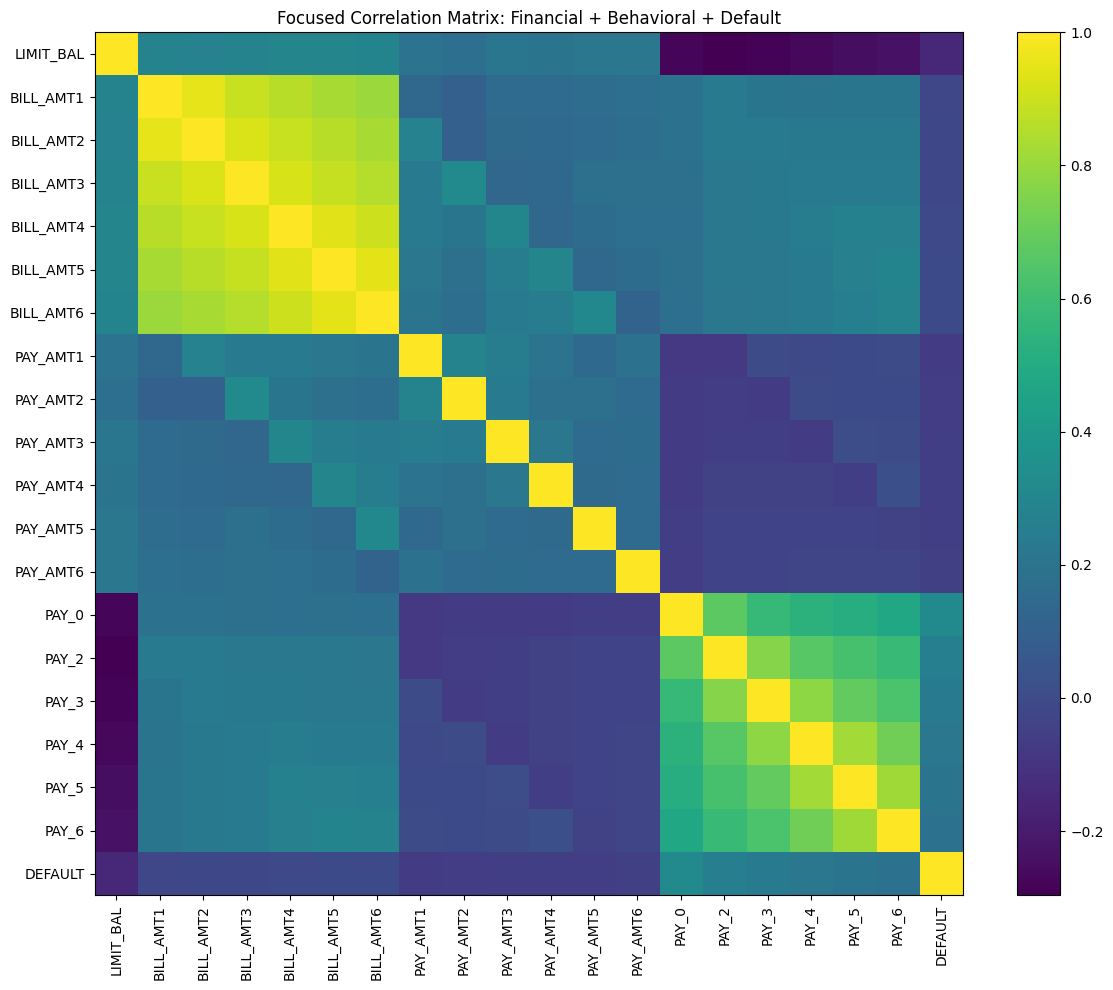

In [33]:
# Focused correlations: financial vs behavioral variables

financial_cols = [
    "LIMIT_BAL",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

focused_cols = financial_cols + pay_cols + ["DEFAULT"]
focused_corr = df[focused_cols].corr()

plt.figure(figsize=(12,10))
plt.imshow(focused_corr, aspect="auto")
plt.colorbar()
plt.title("Focused Correlation Matrix: Financial + Behavioral + Default")
plt.xticks(range(len(focused_corr.columns)), focused_corr.columns, rotation=90)
plt.yticks(range(len(focused_corr.columns)), focused_corr.columns)
plt.tight_layout()
plt.show()

#### 10. Mean comparison by default

Why:
- quick group-level differences

What you found:
- PAY variables shift dramatically
- financial variables shift moderately

Implication:
- reinforces behavioral dominance

In [34]:
# Mean comparison by default

mean_compare = df.groupby("DEFAULT")[financial_cols + pay_cols + ["AGE"]].mean().T
mean_compare.columns = ["No Default", "Default"]

print("\nMean comparison by default status:")
print(mean_compare)


Mean comparison by default status:
              No Default        Default
LIMIT_BAL  178099.726074  130109.656420
BILL_AMT1   51994.227273   48509.162297
BILL_AMT2   49717.435670   47283.617842
BILL_AMT3   47533.365605   45181.598855
BILL_AMT4   43611.165254   42036.950573
BILL_AMT5   40530.445343   39540.190476
BILL_AMT6   39042.268704   38271.435503
PAY_AMT1     6307.337357    3397.044153
PAY_AMT2     6640.465074    3388.649638
PAY_AMT3     5753.496833    3367.351567
PAY_AMT4     5300.529319    3155.626733
PAY_AMT5     5248.220296    3219.139542
PAY_AMT6     5719.371769    3441.482068
PAY_0          -0.211222       0.668174
PAY_2          -0.301917       0.458258
PAY_3          -0.316256       0.362116
PAY_4          -0.355633       0.254521
PAY_5          -0.389488       0.167872
PAY_6          -0.405624       0.112116
AGE            35.417266      35.725738


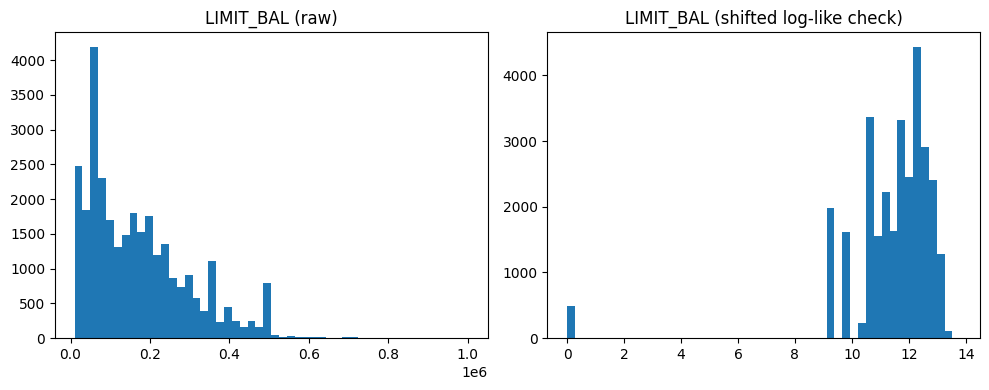

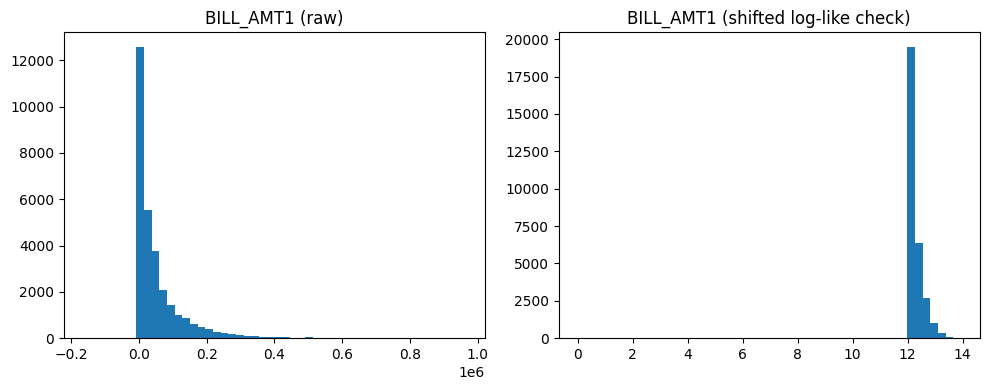

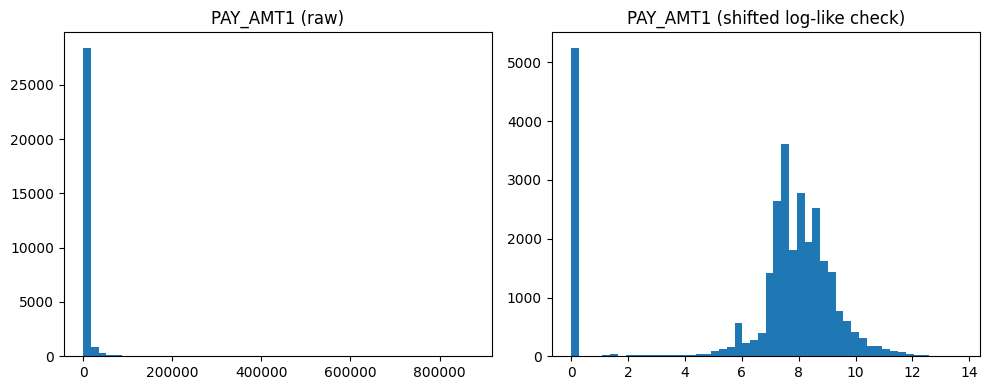

In [35]:
# log-transform checks for skewed variables
skew_check_cols = ["LIMIT_BAL", "BILL_AMT1", "PAY_AMT1"]

for col in skew_check_cols:
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.hist(df[col], bins=50)
    plt.title(f"{col} (raw)")

    plt.subplot(1,2,2)
    plt.hist(np.log1p(df[col] - df[col].min()), bins=50)
    plt.title(f"{col} (shifted log-like check)")

    plt.tight_layout()
    plt.show()

In [39]:
"""If:

ANY_DELAY = 1 : very high default
ANY_DELAY = 0 : low default"""

df["ANY_DELAY"] = (df[pay_cols] > 0).any(axis=1).astype(int)

print(df.groupby("ANY_DELAY")["DEFAULT"].mean())

ANY_DELAY
0    0.117104
1    0.427252
Name: DEFAULT, dtype: float64


In [40]:
# crude comparison via correlation with DEFAULT
df[behavioral_cols + ["DEFAULT"]].corr()["DEFAULT"]
df[financial_cols + ["DEFAULT"]].corr()["DEFAULT"]

LIMIT_BAL   -0.153520
BILL_AMT1   -0.019644
BILL_AMT2   -0.014193
BILL_AMT3   -0.014076
BILL_AMT4   -0.010156
BILL_AMT5   -0.006760
BILL_AMT6   -0.005372
PAY_AMT1    -0.072929
PAY_AMT2    -0.058579
PAY_AMT3    -0.056250
PAY_AMT4    -0.056827
PAY_AMT5    -0.055124
PAY_AMT6    -0.053183
DEFAULT      1.000000
Name: DEFAULT, dtype: float64

## AD-HOC EDA

Conclusions: 
- Behavior dominates.
From ANY_DELAY + MAX_DELAY we see a = strong signal and monotonic relationship.
- Financial variables matter but are diffuse
From LIMIT_BAL plot, boxplots, correlation we see that signal exists but spread across variables.
- Redundancy creates instability
From correlation matrix we see multiple highly correlated blocks
This implies that regression coefficients will compete to explain the same variation.

#### How does this impact regression?

1. Omitted Variable Bias:
when we run $Y = Beta_F * F + \epsilon$, financial variables will absorb behavioral effects and look artificially important.
if we run $Y = \Beta_F * F + \Beta_B * B \epsilon$, we will see $\Beta_F$ shrink, and $\Beta_B$ dominate.
2. Multicollinearity:
Since BILL_AMT variables are redundant, we may see: unstable coefficients, large standard errors, sign changes.
3. Regularization:
Lasso will select one variable from each group. Ridge will shrink all correlated variables.


Full EDA Takeaways:
1. Behavioral variables contain strong, low-dimensional signal.
2. Financial variables contain weaker, distributed signal.
3. Redundancy leads to instability in interpretation.

Key questions for next step:
- Do financial variables remain significant after controlling for behavior?
- Are coefficients stable across specifications?
- Does regularization simplify the model structure?

#### 1. ANY_DELAY:
P(Y=1∣ANY_DELAY=1)−P(Y=1∣ANY_DELAY=0)≈0.427−0.117=0.31

Conclusion: 
- A single bit of behavioral information (any delay or not) explains a huge portion of variation in default.
- If one binary variable already explains a lot, the 6 PAY variables are likely redundant representations of the same underlying signal.

"A simple indicator of whether any repayment delay occurred increases default probability by over 30 percentage points, suggesting that behavioral information alone captures a large portion of credit risk."

In [41]:
df["ANY_DELAY"] = (df[pay_cols] > 0).any(axis=1).astype(int)
df.groupby("ANY_DELAY")["DEFAULT"].mean()

ANY_DELAY
0    0.117104
1    0.427252
Name: DEFAULT, dtype: float64

#### 2. MAX_DELAY
- Collapses 6 PAY dimensions into 1 dimension.
- "Does severity of delinquency matter, not just presence?"

Conclusion:
- Yes, severity of delinquency matters. Strongly and nonlinearly.
- The relationship is: strongly increasing from 0 → 3 and noisy after that. This is because sample size drops for high delays.
- PAY ≥ 6 values are unstable so don’t over-interpret them
- The PAY variables lie on a low-dimensional manifold. Meaning:

"Although we have 6 PAY variables, they effectively behave like 1–2 latent variables: 1) presence of delay, 2) severity of delay." 

#### Additional experiment: compare full PAY vs MAX_DELAY

In [42]:
df["MAX_DELAY"] = df[pay_cols].max(axis=1)
df.groupby("MAX_DELAY")["DEFAULT"].mean()

MAX_DELAY
-2    0.134661
-1    0.147116
 0    0.108306
 1    0.249852
 2    0.435509
 3    0.622307
 4    0.642202
 5    0.507246
 6    0.560000
 7    0.835821
 8    0.560000
Name: DEFAULT, dtype: float64

#### 3. Correlation results (behavioral and financial)

At first glance, it seems like Financial variables don’t matter. However, earlier EDA showed: LIMIT_BAL has a strong monotonic relationship and bill/payment variables show structure.

Issue:
- Correlation is a marginal relationship Corr(X_j, Y) but our models later will estimate a conditional relationship E(Y|X_1, X_2, ..., X_p).
Financial variables look weak because BILL_AMT1–6 are ~0.9 correlated and PAY_AMT1–6 are ~0.7 correlated.
This leads to diluted marginal correlation but meaningful joint effect. i.e. MULTICOLLINEARITY.

"Financial variables exhibit weak marginal correlations with default, likely due to redundancy across multiple highly correlated predictors."



In [43]:
df[behavioral_cols + ["DEFAULT"]].corr()["DEFAULT"]
df[financial_cols + ["DEFAULT"]].corr()["DEFAULT"]

LIMIT_BAL   -0.153520
BILL_AMT1   -0.019644
BILL_AMT2   -0.014193
BILL_AMT3   -0.014076
BILL_AMT4   -0.010156
BILL_AMT5   -0.006760
BILL_AMT6   -0.005372
PAY_AMT1    -0.072929
PAY_AMT2    -0.058579
PAY_AMT3    -0.056250
PAY_AMT4    -0.056827
PAY_AMT5    -0.055124
PAY_AMT6    -0.053183
DEFAULT      1.000000
Name: DEFAULT, dtype: float64

### Changes to Regression Section:
- Add new features (any delay, max delay)
- Add new models:(Behavioral models: full PAY variables, MAX_DELAY only, ANY_DELAY only)
- Compare predictive strength and coefficient stability. 

# Regression

1. OLS (Financial Only, Behavioral Only, Combined)
2. Logistic Regresssion (Financial Only, Behavioral Only, Combined)
3. Ridge and Lasso Logistic (for stability)


### Best Model: financial_plus_num_delay_months. 
- AUC: ~0.735. Consistent across OLS, Logistic, Ridge, Lasso.
- this model beats 1) full behavioral model, 2) full combined model. i.e. more variables dont ensure a better model!
- Interpretation: best model uses financial variables + simple behavioral summary (number of delayed months)

### Behavioral vs Financial 
- Behavioral only: 0.69-0.71
- Financial only: AUC: ~0.63
- Behavioral variables are substantially more predictive than financial variables

### Parsimony / Occam's Razor
- behavioral_full AUC: ~0.686
- behavioral_max_delay AUC: ~0.691
- behavioral_num_delay_months: ~0.713
- Interpretation: simple summary features outperform the full behavioral feature set. **Very strong result**

### Combined models: 
- financial + behavioral_full AUC: ~0.70
- financial + num_delay_months AUC: ~0.735
- Interpretation: adding full behavioral variables hurts performance relative to using summary features.
- Why? Multicollinearity: PAY variables overlap heavily. noise increases. model becomes less efficient

### Any_Delay Result
- financial_plus_any_delay AUC: ~0.721
- Interpretation: any_delay is strong but weaker than num_delay_months. This shows that binary indicator is not a strong enough signal. Intensity (i.e. frequency of delays) not just presence of delays.

### Ridge/Lasso Results
- Almost identical rankings. Regularization does not materially improve performance.
- Interpretation: feature space is not too high-dimensional. Signal is already well captured. Lasso supports our story: simpler models perform just as well.

### Prediction Accuracy (not important)
- ~0.78-0.8
- Misleading because dataset default rate is imbalanced (22%). So, predicting "no default" for every observation will result in ~78% accuracy.
- AUC and log-loss are more important.





In [60]:
# Add summary behavioral variables
df["ANY_DELAY"] = (df[pay_cols] > 0).any(axis=1).astype(int)
df["MAX_DELAY"] = df[pay_cols].max(axis=1)
df["NUM_DELAY_MONTHS"] = (df[pay_cols] > 0).sum(axis=1)

# Optional quick checks
print("Default rate by ANY_DELAY:")
print(df.groupby("ANY_DELAY")["DEFAULT"].mean())

print("\nDefault rate by MAX_DELAY:")
print(df.groupby("MAX_DELAY")["DEFAULT"].mean().sort_index())

print("\nDefault rate by NUM_DELAY_MONTHS:")
print(df.groupby("NUM_DELAY_MONTHS")["DEFAULT"].mean().sort_index())

Default rate by ANY_DELAY:
ANY_DELAY
0    0.117104
1    0.427252
Name: DEFAULT, dtype: float64

Default rate by MAX_DELAY:
MAX_DELAY
-2    0.134661
-1    0.147116
 0    0.108306
 1    0.249852
 2    0.435509
 3    0.622307
 4    0.642202
 5    0.507246
 6    0.560000
 7    0.835821
 8    0.560000
Name: DEFAULT, dtype: float64

Default rate by NUM_DELAY_MONTHS:
NUM_DELAY_MONTHS
0    0.117104
1    0.298238
2    0.387572
3    0.508666
4    0.573081
5    0.573826
6    0.703207
Name: DEFAULT, dtype: float64


In [61]:
# Define model specifications
model_specs = {
    "financial_only": financial_cols,
    "behavioral_full": behavioral_cols,
    "behavioral_any_delay": ["ANY_DELAY"],
    "behavioral_max_delay": ["MAX_DELAY"],
    "behavioral_num_delay_months": ["NUM_DELAY_MONTHS"],
    "financial_plus_behavioral_full": financial_cols + behavioral_cols,
    "financial_plus_any_delay": financial_cols + ["ANY_DELAY"],
    "financial_plus_max_delay": financial_cols + ["MAX_DELAY"],
    "financial_plus_num_delay_months": financial_cols + ["NUM_DELAY_MONTHS"],
    "full_with_demographics": financial_cols + behavioral_cols + demographic_cols,
    "financial_plus_maxdelay_plus_demo": financial_cols + ["MAX_DELAY"] + demographic_cols,
}

In [62]:
# Train/test split
X_all = df.drop(columns=["DEFAULT"])
y_all = df["DEFAULT"]

X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

print("\nTrain/test shapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Train default rate:", round(y_train.mean(), 4))
print("Test  default rate:", round(y_test.mean(), 4))


Train/test shapes:
X_train: (24000, 26)
X_test : (6000, 26)
Train default rate: 0.2212
Test  default rate: 0.2212


In [63]:
# ---------------------------------------------------------
# 6. Evaluation helper
# ---------------------------------------------------------
def evaluate_predictions(y_true, prob, threshold=0.5):
    pred = (prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return {
        "auc": roc_auc_score(y_true, prob),
        "log_loss": log_loss(y_true, prob),
        "accuracy": accuracy_score(y_true, pred),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }

# ---------------------------------------------------------
# 7. Statsmodels helpers: LPM and Logit
# ---------------------------------------------------------
def run_statsmodels_lpm(feature_cols, X_train, X_test, y_train, y_test):
    Xtr = pd.get_dummies(X_train[feature_cols], drop_first=True, dtype=float)
    Xte = pd.get_dummies(X_test[feature_cols], drop_first=True, dtype=float)

    Xtr, Xte = Xtr.align(Xte, join="left", axis=1, fill_value=0.0)

    Xtr = Xtr.astype(float)
    Xte = Xte.astype(float)
    ytr = pd.Series(y_train).astype(float)
    yte = pd.Series(y_test).astype(float)

    Xtr = sm.add_constant(Xtr, has_constant="add")
    Xte = sm.add_constant(Xte, has_constant="add")

    model = sm.OLS(ytr, Xtr).fit(cov_type="HC3")
    pred = model.predict(Xte)
    pred_clip = np.clip(pred, 1e-6, 1 - 1e-6)

    metrics = evaluate_predictions(yte, pred_clip)
    return model, metrics


def run_statsmodels_logit(feature_cols, X_train, X_test, y_train, y_test):
    Xtr = pd.get_dummies(X_train[feature_cols], drop_first=True, dtype=float)
    Xte = pd.get_dummies(X_test[feature_cols], drop_first=True, dtype=float)

    Xtr, Xte = Xtr.align(Xte, join="left", axis=1, fill_value=0.0)

    Xtr = Xtr.astype(float)
    Xte = Xte.astype(float)
    ytr = pd.Series(y_train).astype(float)
    yte = pd.Series(y_test).astype(float)

    Xtr = sm.add_constant(Xtr, has_constant="add")
    Xte = sm.add_constant(Xte, has_constant="add")

    model = sm.Logit(ytr, Xtr).fit(disp=False)
    pred = model.predict(Xte)

    metrics = evaluate_predictions(yte, pred)
    return model, metrics

# ---------------------------------------------------------
# 8. sklearn helpers: ridge and lasso logistic
# ---------------------------------------------------------
def make_preprocessor(feature_cols):
    cat_in_model = [c for c in feature_cols if c in categorical_cols]
    num_in_model = [c for c in feature_cols if c not in categorical_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_in_model),
            ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_in_model),
        ]
    )
    return preprocessor


def run_sklearn_logit(feature_cols, X_train, X_test, y_train, y_test, penalty=None, C=1.0):
    preprocessor = make_preprocessor(feature_cols)

    if penalty is None:
        clf = LogisticRegression(
            penalty=None,
            max_iter=5000,
            solver="lbfgs",
        )
    elif penalty == "l2":
        clf = LogisticRegression(
            penalty="l2",
            C=C,
            max_iter=5000,
            solver="lbfgs",
        )
    elif penalty == "l1":
        clf = LogisticRegression(
            penalty="l1",
            C=C,
            max_iter=5000,
            solver="liblinear",
        )
    else:
        raise ValueError("penalty must be None, 'l1', or 'l2'")

    pipe = Pipeline([
        ("prep", preprocessor),
        ("clf", clf),
    ])

    pipe.fit(X_train[feature_cols], y_train)
    prob = pipe.predict_proba(X_test[feature_cols])[:, 1]
    metrics = evaluate_predictions(y_test, prob)
    return pipe, metrics

In [64]:
# ---------------------------------------------------------
# 9. Run LPM and plain logistic for all model specs
# ---------------------------------------------------------
lpm_results = {}
logit_results = {}

for name, cols in model_specs.items():
    print(f"\nRunning LPM for: {name}")
    lpm_model, lpm_metrics = run_statsmodels_lpm(cols, X_train, X_test, y_train, y_test)
    lpm_results[name] = {"model": lpm_model, "metrics": lpm_metrics}

    print(f"Running logistic regression for: {name}")
    logit_model, logit_metrics = run_statsmodels_logit(cols, X_train, X_test, y_train, y_test)
    logit_results[name] = {"model": logit_model, "metrics": logit_metrics}

lpm_summary = pd.DataFrame({k: v["metrics"] for k, v in lpm_results.items()}).T
logit_summary = pd.DataFrame({k: v["metrics"] for k, v in logit_results.items()}).T

print("\n" + "="*80)
print("LPM test summary:")
print(lpm_summary.sort_values("auc", ascending=False))

print("\n" + "="*80)
print("Logistic test summary:")
print(logit_summary.sort_values("auc", ascending=False))


Running LPM for: financial_only
Running logistic regression for: financial_only

Running LPM for: behavioral_full
Running logistic regression for: behavioral_full

Running LPM for: behavioral_any_delay
Running logistic regression for: behavioral_any_delay

Running LPM for: behavioral_max_delay
Running logistic regression for: behavioral_max_delay

Running LPM for: behavioral_num_delay_months
Running logistic regression for: behavioral_num_delay_months

Running LPM for: financial_plus_behavioral_full
Running logistic regression for: financial_plus_behavioral_full

Running LPM for: financial_plus_any_delay
Running logistic regression for: financial_plus_any_delay

Running LPM for: financial_plus_max_delay
Running logistic regression for: financial_plus_max_delay

Running LPM for: financial_plus_num_delay_months
Running logistic regression for: financial_plus_num_delay_months

Running LPM for: full_with_demographics
Running logistic regression for: full_with_demographics

Running LPM for

In [65]:
# ---------------------------------------------------------
# 10. Run ridge and lasso logistic for all specs
# ---------------------------------------------------------
ridge_results = {}
lasso_results = {}

for name, cols in model_specs.items():
    print(f"\nRunning ridge logistic for: {name}")
    ridge_pipe, ridge_metrics = run_sklearn_logit(
        cols, X_train, X_test, y_train, y_test, penalty="l2", C=1.0
    )
    ridge_results[name] = {"model": ridge_pipe, "metrics": ridge_metrics}

    print(f"Running lasso logistic for: {name}")
    lasso_pipe, lasso_metrics = run_sklearn_logit(
        cols, X_train, X_test, y_train, y_test, penalty="l1", C=1.0
    )
    lasso_results[name] = {"model": lasso_pipe, "metrics": lasso_metrics}

ridge_summary = pd.DataFrame({k: v["metrics"] for k, v in ridge_results.items()}).T
lasso_summary = pd.DataFrame({k: v["metrics"] for k, v in lasso_results.items()}).T

print("\n" + "="*80)
print("Ridge logistic test summary:")
print(ridge_summary.sort_values("auc", ascending=False))

print("\n" + "="*80)
print("Lasso logistic test summary:")
print(lasso_summary.sort_values("auc", ascending=False))


Running ridge logistic for: financial_only
Running lasso logistic for: financial_only

Running ridge logistic for: behavioral_full
Running lasso logistic for: behavioral_full

Running ridge logistic for: behavioral_any_delay
Running lasso logistic for: behavioral_any_delay

Running ridge logistic for: behavioral_max_delay
Running lasso logistic for: behavioral_max_delay

Running ridge logistic for: behavioral_num_delay_months
Running lasso logistic for: behavioral_num_delay_months

Running ridge logistic for: financial_plus_behavioral_full
Running lasso logistic for: financial_plus_behavioral_full

Running ridge logistic for: financial_plus_any_delay
Running lasso logistic for: financial_plus_any_delay

Running ridge logistic for: financial_plus_max_delay
Running lasso logistic for: financial_plus_max_delay

Running ridge logistic for: financial_plus_num_delay_months
Running lasso logistic for: financial_plus_num_delay_months

Running ridge logistic for: full_with_demographics
Running

In [66]:
# ---------------------------------------------------------
# 11. Show core coefficient tables / summaries
# ---------------------------------------------------------
core_specs = [
    "financial_only",
    "behavioral_full",
    "behavioral_any_delay",
    "behavioral_max_delay",
    "behavioral_num_delay_months",
    "financial_plus_behavioral_full",
    "financial_plus_any_delay",
    "financial_plus_max_delay",
    "financial_plus_num_delay_months",
]

for spec in core_specs:
    print("\n" + "="*80)
    print(f"LPM summary: {spec}")
    print(lpm_results[spec]["model"].summary())

for spec in core_specs:
    print("\n" + "="*80)
    print(f"Logit summary: {spec}")
    print(logit_results[spec]["model"].summary())




LPM summary: financial_only
                            OLS Regression Results                            
Dep. Variable:                DEFAULT   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     63.15
Date:                Mon, 06 Apr 2026   Prob (F-statistic):          3.61e-164
Time:                        19:56:23   Log-Likelihood:                -12554.
No. Observations:               24000   AIC:                         2.514e+04
Df Residuals:                   23986   BIC:                         2.525e+04
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3044  

In [67]:
# ---------------------------------------------------------
# 12. Compact coefficient extraction tables (optional but useful)
# ---------------------------------------------------------
def extract_coef_table(sm_model, model_name):
    coef = sm_model.params
    se = sm_model.bse
    pval = sm_model.pvalues

    out = pd.DataFrame({
        "coef": coef,
        "std_err": se,
        "p_value": pval,
    })
    out["model"] = model_name
    return out.reset_index().rename(columns={"index": "variable"})

coef_tables_lpm = []
coef_tables_logit = []

for spec in core_specs:
    coef_tables_lpm.append(extract_coef_table(lpm_results[spec]["model"], f"LPM_{spec}"))
    coef_tables_logit.append(extract_coef_table(logit_results[spec]["model"], f"LOGIT_{spec}"))

coef_table_lpm = pd.concat(coef_tables_lpm, ignore_index=True)
coef_table_logit = pd.concat(coef_tables_logit, ignore_index=True)

print("\n" + "="*80)
print("Example extracted coefficient table (LPM):")
print(coef_table_lpm.head(20))

print("\n" + "="*80)
print("Example extracted coefficient table (LOGIT):")
print(coef_table_logit.head(20))




Example extracted coefficient table (LPM):
     variable          coef       std_err        p_value                model
0       const  3.043769e-01  4.748676e-03   0.000000e+00   LPM_financial_only
1   LIMIT_BAL -4.886628e-07  2.681333e-08   3.291470e-74   LPM_financial_only
2   BILL_AMT1 -4.368344e-07  1.462048e-07   2.809694e-03   LPM_financial_only
3   BILL_AMT2  2.758714e-07  2.152930e-07   2.000615e-01   LPM_financial_only
4   BILL_AMT3 -6.595115e-08  2.648542e-07   8.033536e-01   LPM_financial_only
5   BILL_AMT4  1.136277e-07  1.772016e-07   5.213708e-01   LPM_financial_only
6   BILL_AMT5  2.443098e-07  2.520827e-07   3.324627e-01   LPM_financial_only
7   BILL_AMT6  3.158316e-07  2.190176e-07   1.492919e-01   LPM_financial_only
8    PAY_AMT1 -1.145592e-06  3.462676e-07   9.383069e-04   LPM_financial_only
9    PAY_AMT2 -4.679961e-07  4.508271e-07   2.992313e-01   LPM_financial_only
10   PAY_AMT3 -3.392008e-07  2.671772e-07   2.042370e-01   LPM_financial_only
11   PAY_AMT4 -5.466

In [68]:
# ---------------------------------------------------------
# 13. Focused comparison for key variables across models
# ---------------------------------------------------------
key_vars = [
    "LIMIT_BAL",
    "BILL_AMT1",
    "PAY_AMT1",
    "PAY_0",
    "PAY_2",
    "ANY_DELAY",
    "MAX_DELAY",
    "NUM_DELAY_MONTHS",
]

def build_key_comparison(results_dict, specs, model_prefix):
    rows = []
    for spec in specs:
        model = results_dict[spec]["model"]
        params = model.params
        pvals = model.pvalues

        row = {"model": f"{model_prefix}_{spec}"}
        for var in key_vars:
            row[f"{var}_coef"] = params[var] if var in params.index else np.nan
            row[f"{var}_p"] = pvals[var] if var in pvals.index else np.nan
        rows.append(row)
    return pd.DataFrame(rows)

lpm_key_compare = build_key_comparison(lpm_results, core_specs, "LPM")
logit_key_compare = build_key_comparison(logit_results, core_specs, "LOGIT")

print("\n" + "="*80)
print("Key coefficient comparison: LPM")
print(lpm_key_compare)

print("\n" + "="*80)
print("Key coefficient comparison: LOGIT")
print(logit_key_compare)


Key coefficient comparison: LPM
                                 model  LIMIT_BAL_coef   LIMIT_BAL_p  \
0                   LPM_financial_only   -4.886628e-07  3.291470e-74   
1                  LPM_behavioral_full             NaN           NaN   
2             LPM_behavioral_any_delay             NaN           NaN   
3             LPM_behavioral_max_delay             NaN           NaN   
4      LPM_behavioral_num_delay_months             NaN           NaN   
5   LPM_financial_plus_behavioral_full   -7.266261e-08  1.562580e-03   
6         LPM_financial_plus_any_delay   -2.896115e-07  6.924587e-40   
7         LPM_financial_plus_max_delay   -1.501471e-07  7.653670e-11   
8  LPM_financial_plus_num_delay_months   -1.974539e-07  9.420029e-21   

   BILL_AMT1_coef  BILL_AMT1_p  PAY_AMT1_coef  PAY_AMT1_p  PAY_0_coef  \
0   -4.368344e-07     0.002810  -1.145592e-06    0.000938         NaN   
1             NaN          NaN            NaN         NaN    0.097760   
2             NaN          

### Additional Plots for Final Report

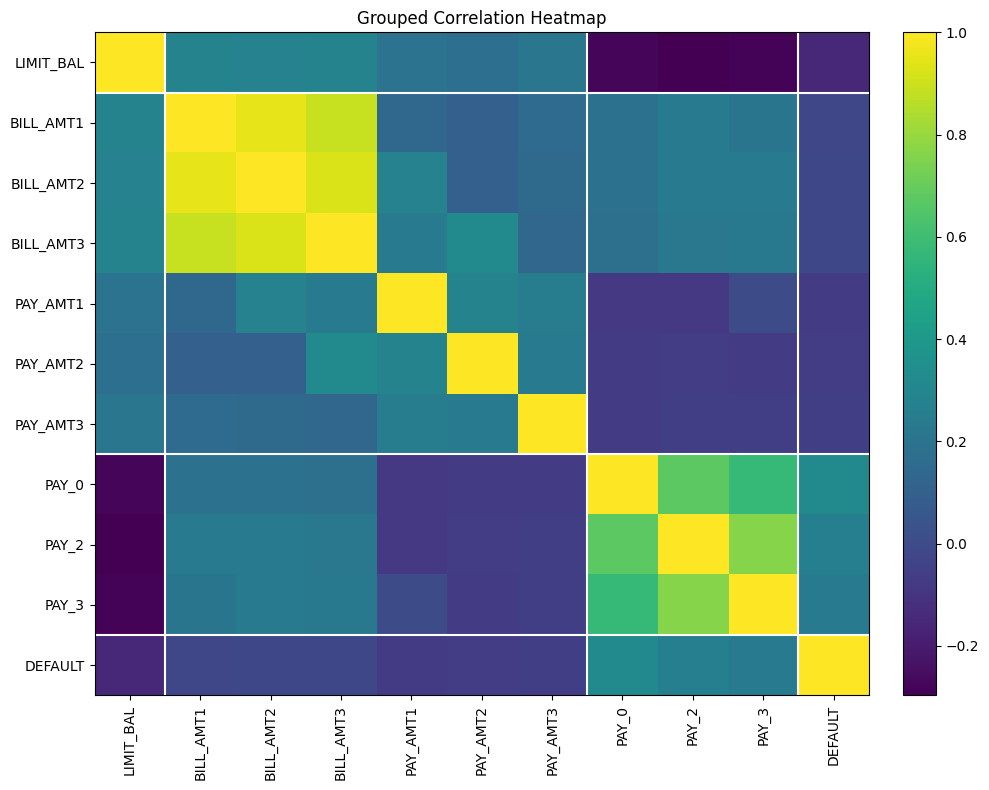

In [69]:
grouped_cols = [
    "LIMIT_BAL",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_0", "PAY_2", "PAY_3",
    "DEFAULT"
]

corr = df[grouped_cols].corr()

plt.figure(figsize=(10, 8))
im = plt.imshow(corr, aspect="auto")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("Grouped Correlation Heatmap")
plt.xticks(range(len(grouped_cols)), grouped_cols, rotation=90)
plt.yticks(range(len(grouped_cols)), grouped_cols)

# optional guide lines to show blocks
for pos in [1, 7, 10]:
    plt.axhline(pos - 0.5, color="white", linewidth=1.5)
    plt.axvline(pos - 0.5, color="white", linewidth=1.5)

plt.tight_layout()
plt.show()

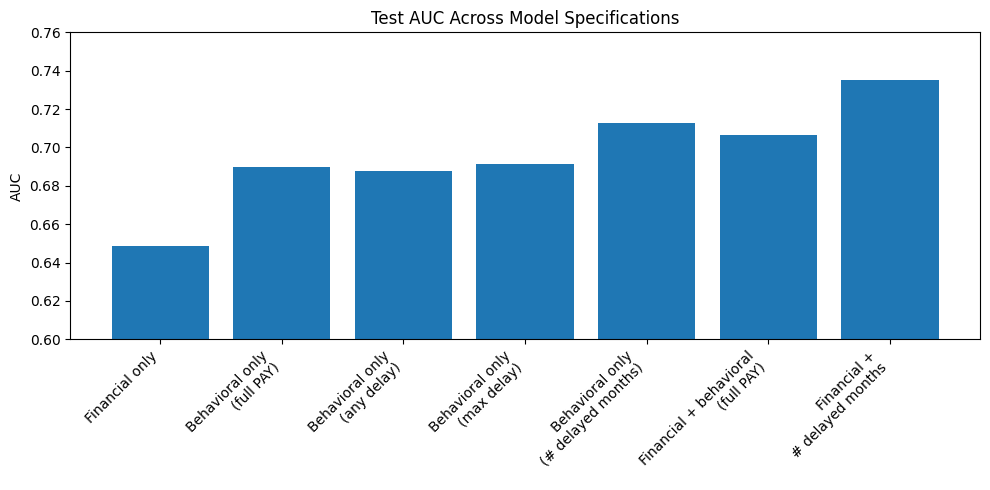

In [74]:
report_models = [
    "financial_only",
    "behavioral_full",
    "behavioral_any_delay",
    "behavioral_max_delay",
    "behavioral_num_delay_months",
    "financial_plus_behavioral_full",
    "financial_plus_num_delay_months",
]

pretty_names = {
    "financial_only": "Financial only",
    "behavioral_full": "Behavioral only\n(full PAY)",
    "behavioral_any_delay": "Behavioral only\n(any delay)",
    "behavioral_max_delay": "Behavioral only\n(max delay)",
    "behavioral_num_delay_months": "Behavioral only\n(# delayed months)",
    "financial_plus_behavioral_full": "Financial + behavioral\n(full PAY)",
    "financial_plus_num_delay_months": "Financial +\n# delayed months",
}

plot_perf = logit_summary.loc[report_models, ["auc"]].copy()
plot_perf["label"] = [pretty_names[m] for m in plot_perf.index]

plt.figure(figsize=(10, 5))
plt.bar(plot_perf["label"], plot_perf["auc"])

plt.title("Test AUC Across Model Specifications")
plt.ylabel("AUC")
plt.ylim(0.60, 0.76)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

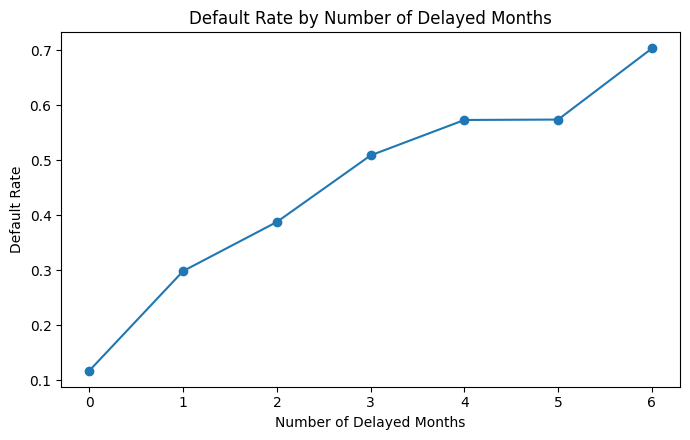

In [71]:
numdelay_tab = df.groupby("NUM_DELAY_MONTHS")["DEFAULT"].mean().sort_index()

plt.figure(figsize=(7, 4.5))
plt.plot(numdelay_tab.index, numdelay_tab.values, marker="o")
plt.title("Default Rate by Number of Delayed Months")
plt.xlabel("Number of Delayed Months")
plt.ylabel("Default Rate")
plt.tight_layout()
plt.show()

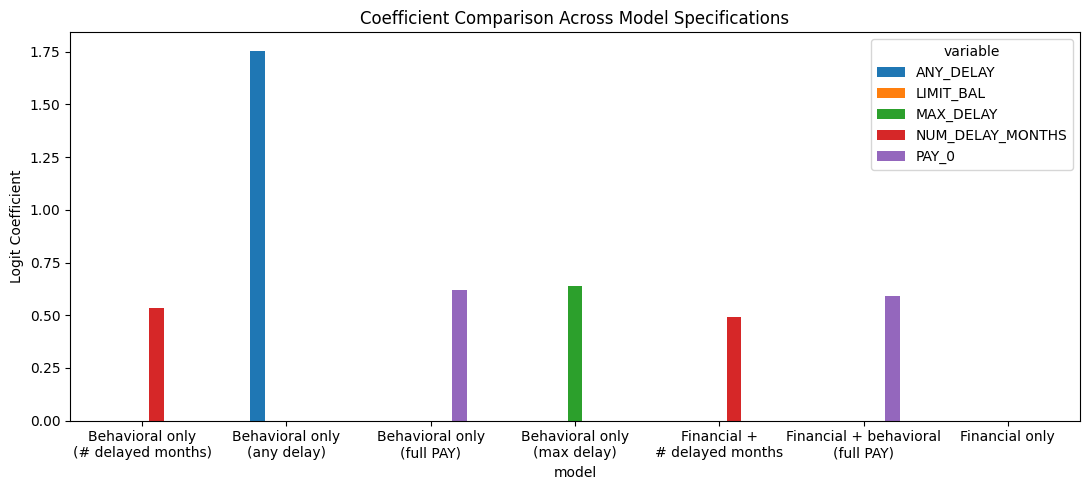

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

report_models = [
    "financial_only",
    "behavioral_full",
    "behavioral_any_delay",
    "behavioral_max_delay",
    "behavioral_num_delay_months",
    "financial_plus_behavioral_full",
    "financial_plus_num_delay_months",
]

pretty_names = {
    "financial_only": "Financial only",
    "behavioral_full": "Behavioral only\n(full PAY)",
    "behavioral_any_delay": "Behavioral only\n(any delay)",
    "behavioral_max_delay": "Behavioral only\n(max delay)",
    "behavioral_num_delay_months": "Behavioral only\n(# delayed months)",
    "financial_plus_behavioral_full": "Financial + behavioral\n(full PAY)",
    "financial_plus_num_delay_months": "Financial +\n# delayed months",
}

key_vars = ["LIMIT_BAL", "PAY_0", "ANY_DELAY", "MAX_DELAY", "NUM_DELAY_MONTHS"]

rows = []
for spec in report_models:
    model = logit_results[spec]["model"]
    for var in key_vars:
        if var in model.params.index:
            rows.append({
                "model": pretty_names[spec],
                "variable": var,
                "coef": model.params[var]
            })

coef_long = pd.DataFrame(rows)

pivot = coef_long.pivot(index="model", columns="variable", values="coef")
pivot.plot(kind="bar", figsize=(11, 5))
plt.title("Coefficient Comparison Across Model Specifications")
plt.ylabel("Logit Coefficient")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [75]:
# ---------------------------------------------------------
# Table 1: Model performance summary
# ---------------------------------------------------------

# Models to include in report
report_models = [
    "financial_only",
    "behavioral_full",
    "behavioral_any_delay",
    "behavioral_max_delay",
    "behavioral_num_delay_months",
    "financial_plus_behavioral_full",
    "financial_plus_num_delay_months",
]

# Clean names for report
pretty_names = {
    "financial_only": "Financial only",
    "behavioral_full": "Behavioral only (full PAY)",
    "behavioral_any_delay": "Behavioral only (any delay)",
    "behavioral_max_delay": "Behavioral only (max delay)",
    "behavioral_num_delay_months": "Behavioral only (# delayed months)",
    "financial_plus_behavioral_full": "Financial + behavioral (full PAY)",
    "financial_plus_num_delay_months": "Financial + # delayed months",
}

# Select and clean table
table1 = (
    logit_summary.loc[report_models, ["auc", "log_loss", "accuracy"]]
    .rename(index=pretty_names)
    .sort_values("auc", ascending=False)
)

# Round for readability
table1 = table1.round(4)

# Print nicely
print("\nTable 1: Model Performance Summary\n")
print(table1)
print(table1.to_markdown())


Table 1: Model Performance Summary

                                       auc  log_loss  accuracy
Financial + # delayed months        0.7353    0.4600    0.8015
Behavioral only (# delayed months)  0.7128    0.4646    0.8022
Financial + behavioral (full PAY)   0.7063    0.4720    0.8092
Behavioral only (max delay)         0.6913    0.4811    0.7905
Behavioral only (full PAY)          0.6901    0.4783    0.8085
Behavioral only (any delay)         0.6879    0.4763    0.7788
Financial only                      0.6487    0.5081    0.7788
|                                    |    auc |   log_loss |   accuracy |
|:-----------------------------------|-------:|-----------:|-----------:|
| Financial + # delayed months       | 0.7353 |     0.46   |     0.8015 |
| Behavioral only (# delayed months) | 0.7128 |     0.4646 |     0.8022 |
| Financial + behavioral (full PAY)  | 0.7063 |     0.472  |     0.8092 |
| Behavioral only (max delay)        | 0.6913 |     0.4811 |     0.7905 |
| Behavioral on

In [78]:
# ---------------------------------------------------------
# Table 2: Key coefficient comparison, formatted for report
# ---------------------------------------------------------

report_models = [
    "financial_only",
    "behavioral_full",
    "behavioral_any_delay",
    "behavioral_max_delay",
    "behavioral_num_delay_months",
    "financial_plus_behavioral_full",
    "financial_plus_num_delay_months",
]

pretty_names = {
    "financial_only": "Financial only",
    "behavioral_full": "Behavioral only (full PAY)",
    "behavioral_any_delay": "Behavioral only (any delay)",
    "behavioral_max_delay": "Behavioral only (max delay)",
    "behavioral_num_delay_months": "Behavioral only (# delayed months)",
    "financial_plus_behavioral_full": "Financial + behavioral (full PAY)",
    "financial_plus_num_delay_months": "Financial + # delayed months",
}

key_vars = ["LIMIT_BAL", "PAY_0", "ANY_DELAY", "MAX_DELAY", "NUM_DELAY_MONTHS"]

def format_coef_p(coef, p):
    if pd.isna(coef):
        return ""
    if p < 0.001:
        p_str = "p<0.001"
    else:
        p_str = f"p={p:.3f}"
    return f"{coef:.4f} ({p_str})"

rows = []
for spec in report_models:
    model = logit_results[spec]["model"]
    row = {"Model": pretty_names[spec]}
    for var in key_vars:
        if var in model.params.index:
            row[var] = format_coef_p(model.params[var], model.pvalues[var])
        else:
            row[var] = ""
    rows.append(row)

table2_final = pd.DataFrame(rows)

print("\nTable 2: Key Coefficient Comparison\n")
print(table2_final)
print(table2_final.to_markdown(index=False))


Table 2: Key Coefficient Comparison

                                Model          LIMIT_BAL             PAY_0  \
0                      Financial only  -0.0000 (p<0.001)                     
1          Behavioral only (full PAY)                     0.6215 (p<0.001)   
2         Behavioral only (any delay)                                        
3         Behavioral only (max delay)                                        
4  Behavioral only (# delayed months)                                        
5   Financial + behavioral (full PAY)  -0.0000 (p<0.001)  0.5888 (p<0.001)   
6        Financial + # delayed months  -0.0000 (p<0.001)                     

          ANY_DELAY         MAX_DELAY  NUM_DELAY_MONTHS  
0                                                        
1                                                        
2  1.7547 (p<0.001)                                      
3                    0.6373 (p<0.001)                    
4                                      0.5327 (

In [80]:
group_perf = table1.loc[
    [
        "Financial only",
        "Behavioral only (full PAY)",
        "Behavioral only (# delayed months)",
        "Financial + # delayed months",
    ]
]

print(group_perf)

                                       auc  log_loss  accuracy
Financial only                      0.6487    0.5081    0.7788
Behavioral only (full PAY)          0.6901    0.4783    0.8085
Behavioral only (# delayed months)  0.7128    0.4646    0.8022
Financial + # delayed months        0.7353    0.4600    0.8015


## Delinquency Regime Split

In [82]:

# Define regimes
# Regime 1: no observed delinquency
df["DELINQ_REGIME"] = np.where(df["ANY_DELAY"] == 1, "Delinquent", "Non-delinquent")

print(df["DELINQ_REGIME"].value_counts())
print(df.groupby("DELINQ_REGIME")["DEFAULT"].mean())

# ---------------------------------------------------------
# 2. Evaluation helper
# ---------------------------------------------------------
def evaluate_predictions(y_true, prob, threshold=0.5):
    pred = (prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return {
        "auc": roc_auc_score(y_true, prob),
        "log_loss": log_loss(y_true, prob),
        "accuracy": accuracy_score(y_true, pred),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }

# ---------------------------------------------------------
# 3. Statsmodels logit helper
# ---------------------------------------------------------
import numpy as np
import pandas as pd
import statsmodels.api as sm
from numpy.linalg import matrix_rank
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss, accuracy_score, confusion_matrix

def evaluate_predictions(y_true, prob, threshold=0.5):
    pred = (prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return {
        "auc": roc_auc_score(y_true, prob),
        "log_loss": log_loss(y_true, prob),
        "accuracy": accuracy_score(y_true, pred),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }

def prepare_design_matrix(X_train, X_test, feature_cols):
    Xtr = pd.get_dummies(X_train[feature_cols], drop_first=True, dtype=float)
    Xte = pd.get_dummies(X_test[feature_cols], drop_first=True, dtype=float)

    # Align columns
    Xtr, Xte = Xtr.align(Xte, join="left", axis=1, fill_value=0.0)

    # Drop constant columns in training set
    constant_cols = [c for c in Xtr.columns if Xtr[c].nunique() <= 1]
    if constant_cols:
        Xtr = Xtr.drop(columns=constant_cols)
        Xte = Xte.drop(columns=constant_cols, errors="ignore")

    # Drop duplicate columns
    Xtr_T = Xtr.T
    dup_mask = Xtr_T.duplicated()
    dup_cols = Xtr_T.index[dup_mask].tolist()
    if dup_cols:
        Xtr = Xtr.drop(columns=dup_cols)
        Xte = Xte.drop(columns=dup_cols, errors="ignore")

    # Add constant
    Xtr = sm.add_constant(Xtr, has_constant="add")
    Xte = sm.add_constant(Xte, has_constant="add")

    return Xtr.astype(float), Xte.astype(float)

def run_statsmodels_logit_safe(feature_cols, X_train, X_test, y_train, y_test, verbose=True):
    Xtr, Xte = prepare_design_matrix(X_train, X_test, feature_cols)
    ytr = pd.Series(y_train).astype(float)
    yte = pd.Series(y_test).astype(float)

    # Rank check
    rank = matrix_rank(Xtr.values)
    ncols = Xtr.shape[1]
    if verbose:
        print(f"Design matrix shape: {Xtr.shape}, rank: {rank}")

    # If rank deficient, drop collinear columns greedily
    if rank < ncols:
        keep_cols = []
        current = pd.DataFrame(index=Xtr.index)

        for col in Xtr.columns:
            trial = pd.concat([current, Xtr[[col]]], axis=1)
            if matrix_rank(trial.values) == trial.shape[1]:
                keep_cols.append(col)
                current = trial

        dropped = [c for c in Xtr.columns if c not in keep_cols]
        if verbose and dropped:
            print("Dropped collinear columns:", dropped)

        Xtr = Xtr[keep_cols]
        Xte = Xte[keep_cols]

    try:
        model = sm.Logit(ytr, Xtr).fit(disp=False, maxiter=200)
        pred = model.predict(Xte)
        metrics = evaluate_predictions(yte, pred)
        return {
            "engine": "statsmodels",
            "model": model,
            "metrics": metrics,
            "columns": Xtr.columns.tolist()
        }
    except Exception as e:
        if verbose:
            print("statsmodels Logit failed, falling back to sklearn LogisticRegression")
            print("Error:", repr(e))

        # Fallback to sklearn regularized logistic
        clf = LogisticRegression(
            penalty="l2",
            C=1.0,
            max_iter=5000,
            solver="lbfgs"
        )
        clf.fit(Xtr, ytr)
        pred = clf.predict_proba(Xte)[:, 1]
        metrics = evaluate_predictions(yte, pred)

        coef = pd.Series(clf.coef_.ravel(), index=Xtr.columns)
        return {
            "engine": "sklearn_fallback",
            "model": clf,
            "coef": coef,
            "metrics": metrics,
            "columns": Xtr.columns.tolist()
        }

# ---------------------------------------------------------
# 4. Run models separately by regime
# ---------------------------------------------------------
regime_specs = {
    "financial_only": financial_cols,
    "behavioral_full": behavioral_cols,
    "behavioral_num_delay_months": ["NUM_DELAY_MONTHS"],
    "financial_plus_behavioral_full": financial_cols + behavioral_cols,
    "financial_plus_num_delay_months": financial_cols + ["NUM_DELAY_MONTHS"],
}

all_regime_results = {}

for regime in ["Non-delinquent", "Delinquent"]:
    print(f"\n{'='*80}")
    print(f"REGIME: {regime}")
    print(f"{'='*80}")

    sub = df[df["DELINQ_REGIME"] == regime].copy()

    X_sub = sub.drop(columns=["DEFAULT", "DELINQ_REGIME"])
    y_sub = sub["DEFAULT"]

    X_train, X_test, y_train, y_test = train_test_split(
        X_sub,
        y_sub,
        test_size=0.2,
        random_state=42,
        stratify=y_sub
    )

    regime_results = {}

    for spec_name, cols in regime_specs.items():
        print(f"\nRunning {spec_name}...")
        res = run_statsmodels_logit_safe(cols, X_train, X_test, y_train, y_test, verbose=True)
        regime_results[spec_name] = res

    all_regime_results[regime] = regime_results

# ---------------------------------------------------------
# 5. Summarize out-of-sample performance by regime
# ---------------------------------------------------------
summary_rows = []

pretty_names = {
    "financial_only": "Financial only",
    "behavioral_full": "Behavioral only (full PAY)",
    "behavioral_num_delay_months": "Behavioral only (# delayed months)",
    "financial_plus_behavioral_full": "Financial + behavioral (full PAY)",
    "financial_plus_num_delay_months": "Financial + # delayed months",
}

for regime, results in all_regime_results.items():
    for spec_name, res in results.items():
        row = {
            "Regime": regime,
            "Model": pretty_names[spec_name],
            "Engine": res["engine"],
        }
        row.update(res["metrics"])
        summary_rows.append(row)

regime_perf = pd.DataFrame(summary_rows).sort_values(["Regime", "auc"], ascending=[True, False])

print(regime_perf[["Regime", "Model", "Engine", "auc", "log_loss", "accuracy"]].round(4))

# ---------------------------------------------------------
# 6. Extract a few key coefficients by regime
# ---------------------------------------------------------
key_vars = ["LIMIT_BAL", "PAY_0", "NUM_DELAY_MONTHS"]

coef_rows = []
for regime, results in all_regime_results.items():
    for spec_name, res in results.items():
        model = res["model"]
        row = {"Regime": regime, "Model": pretty_names[spec_name]}
        for var in key_vars:
            row[f"{var}_coef"] = model.params[var] if var in model.params.index else np.nan
            row[f"{var}_p"] = model.pvalues[var] if var in model.pvalues.index else np.nan
        coef_rows.append(row)

regime_coef = pd.DataFrame(coef_rows)
print("\nRegime-specific key coefficients:")
print(regime_coef.round(4))

DELINQ_REGIME
Non-delinquent    19931
Delinquent        10069
Name: count, dtype: int64
DELINQ_REGIME
Delinquent        0.427252
Non-delinquent    0.117104
Name: DEFAULT, dtype: float64

REGIME: Non-delinquent

Running financial_only...
Design matrix shape: (15944, 14), rank: 14

Running behavioral_full...
Design matrix shape: (15944, 7), rank: 7

Running behavioral_num_delay_months...
Design matrix shape: (15944, 1), rank: 1

Running financial_plus_behavioral_full...
Design matrix shape: (15944, 20), rank: 20

Running financial_plus_num_delay_months...
Design matrix shape: (15944, 14), rank: 14

REGIME: Delinquent

Running financial_only...
Design matrix shape: (8055, 14), rank: 14

Running behavioral_full...
Design matrix shape: (8055, 7), rank: 7

Running behavioral_num_delay_months...
Design matrix shape: (8055, 2), rank: 2

Running financial_plus_behavioral_full...
Design matrix shape: (8055, 20), rank: 20

Running financial_plus_num_delay_months...
Design matrix shape: (8055, 15)